In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Cargar el csv
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Mostrar las primeras 5 filas para confirmar la carga
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


             Age  MonthlyIncome  YearsAtCompany  YearsSinceLastPromotion  \
Attrition                                                                  
No         37.56        6832.74            7.37                     2.23   
Yes        33.61        4787.09            5.13                     1.95   

           JobSatisfaction  WorkLifeBalance  
Attrition                                    
No                    2.78             2.78  
Yes                   2.47             2.66  


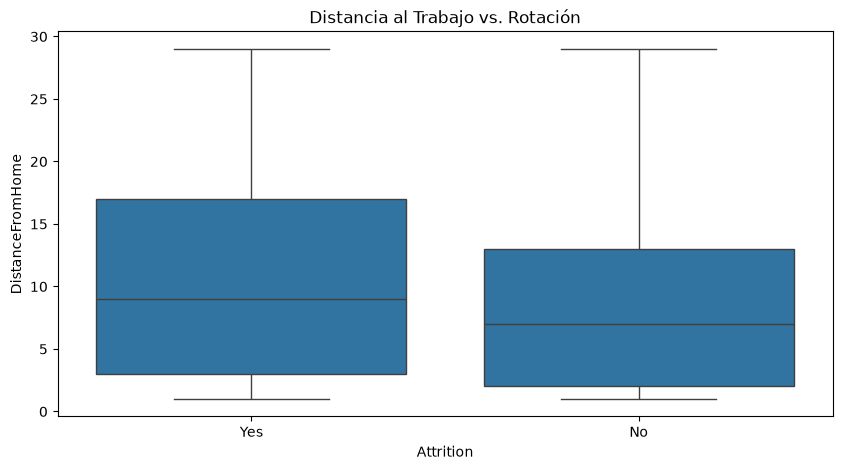

Attrition        No       Yes
OverTime                     
No         0.895636  0.104364
Yes        0.694712  0.305288
Attrition_num              1.000000
DistanceFromHome           0.077924
NumCompaniesWorked         0.043494
MonthlyRate                0.015170
PerformanceRating          0.002889
HourlyRate                -0.006846
EmployeeNumber            -0.010577
PercentSalaryHike         -0.013478
Education                 -0.031373
YearsSinceLastPromotion   -0.033019
Name: Attrition_num, dtype: float64
YearsAtCompany         -0.134392
StockOptionLevel       -0.137145
YearsWithCurrManager   -0.156199
Age                    -0.159205
MonthlyIncome          -0.159840
YearsInCurrentRole     -0.160545
JobLevel               -0.169105
TotalWorkingYears      -0.171063
EmployeeCount                NaN
StandardHours                NaN
Name: Attrition_num, dtype: float64


In [3]:
# Perfil del empleado que se va vs. el que se queda
attrition_profile = df.groupby('Attrition').agg({
    'Age': 'mean',
    'MonthlyIncome': 'mean',
    'YearsAtCompany': 'mean',
    'YearsSinceLastPromotion': 'mean',
    'JobSatisfaction': 'mean',
    'WorkLifeBalance': 'mean'
}).round(2)
print(attrition_profile)

# Visualización: ¿La distancia al trabajo influye?
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome')
plt.title('Distancia al Trabajo vs. Rotación')
plt.show()

# Tabla cruzada: ¿El overtime está relacionado con la rotación?
overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')
print(overtime_attrition)

# Correlación de todas las variables numéricas con Attrition
# (Convertimos Attrition a numérico primero)
df['Attrition_num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['Attrition_num'].sort_values(ascending=False)
print(correlations.head(10))  # Top 10 correlaciones positivas
print(correlations.tail(10))  # Top 10 correlaciones negativas

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_num
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,0.161224
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,0.367863
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,0.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,1.000000


In [6]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
# Eliminar columnas sin variabilidad informativa
df = df.drop(columns=['StandardHours', 'EmployeeCount', 'Over18'])

In [8]:
df.shape

(1470, 33)

In [9]:
# Mapeo binario para OverTime (1 = Hace horas extra, 0 = No)
df['OverTime_num'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# Mapeo binario para Gender (1 = Male, 0 = Female)
df['Gender_num'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Verificar que los nuevos campos se hayan creado correctamente
df[['OverTime', 'OverTime_num', 'Gender', 'Gender_num']].head()

,OverTime,OverTime_num,Gender,Gender_num
0,Yes,1,Female,0
1,No,0,Male,1
2,Yes,1,Male,1
3,Yes,1,Female,0
4,No,0,Male,1


In [10]:
#Rotación promedio por departamento
df.groupby('Department')['Attrition_num'].mean()* 100

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition_num, dtype: float64

In [11]:
df['Department'].nunique()

3

In [12]:
df['JobRole'].nunique()

9

In [13]:
#Observamos el porcentaje de rotación por puesto
(df.groupby('JobRole')['Attrition_num'].mean().sort_values(ascending=False)) * 100

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition_num, dtype: float64

In [14]:
# Se reonmbran los puestos del dataset para ajustarlo al proyecto de HR Aanalytics de una empresa de retail de lujo 
# Diccionario de mapeo
role_mapping = {
    'Sales Representative': 'Client Advisor',
    'Laboratory Technician': 'Atelier Technician',
    'Human Resources': 'People & Culture Coordinator',
    'Sales Executive': 'Assistant Boutique Manager',
    'Research Scientist': 'Junior Designer',
    'Healthcare Representative': 'Visual Merchandiser',
    'Manufacturing Director': 'Atelier Director',
    'Manager': 'Boutique Manager',
    'Research Director': 'Creative Director'
}

# Aplicar
df['JobRole_Luxury'] = df['JobRole'].map(role_mapping)

# Verificar que la rotación se mantiene igual
(df.groupby('JobRole_Luxury')['Attrition_num'].mean().sort_values(ascending=False)) * 100

JobRole_Luxury
Client Advisor                  39.759036
Atelier Technician              23.938224
People & Culture Coordinator    23.076923
Assistant Boutique Manager      17.484663
Junior Designer                 16.095890
Atelier Director                 6.896552
Visual Merchandiser              6.870229
Boutique Manager                 4.901961
Creative Director                2.500000
Name: Attrition_num, dtype: float64

In [15]:
#Agrupamos para ver como influye hacer horas extras el porcentaje de renuncia por puesto
(df.groupby(['JobRole_Luxury', 'OverTime'])['Attrition_num'].mean() * 100)

JobRole_Luxury                OverTime
Assistant Boutique Manager    No          11.206897
                              Yes         32.978723
Atelier Director              No           5.660377
                              Yes         10.256410
Atelier Technician            No          15.736041
                              Yes         50.000000
Boutique Manager              No           1.333333
                              Yes         14.814815
Client Advisor                No          28.813559
                              Yes         66.666667
Creative Director             No           1.754386
                              Yes          4.347826
Junior Designer               No           7.179487
                              Yes         34.020619
People & Culture Coordinator  No          17.948718
                              Yes         38.461538
Visual Merchandiser           No           7.446809
                              Yes          5.405405
Name: Attrition_num, dtyp

In [16]:
# Usamos la función unstack para tener una visualizacion más limpia
(df.groupby(['JobRole_Luxury', 'OverTime'])['Attrition_num'].mean() * 100).unstack().round(2)

OverTime,No,Yes
JobRole_Luxury,,
Assistant Boutique Manager,11.21,32.98
Atelier Director,5.66,10.26
Atelier Technician,15.74,50.00
Boutique Manager,1.33,14.81
Client Advisor,28.81,66.67
Creative Director,1.75,4.35
Junior Designer,7.18,34.02
People & Culture Coordinator,17.95,38.46
Visual Merchandiser,7.45,5.41


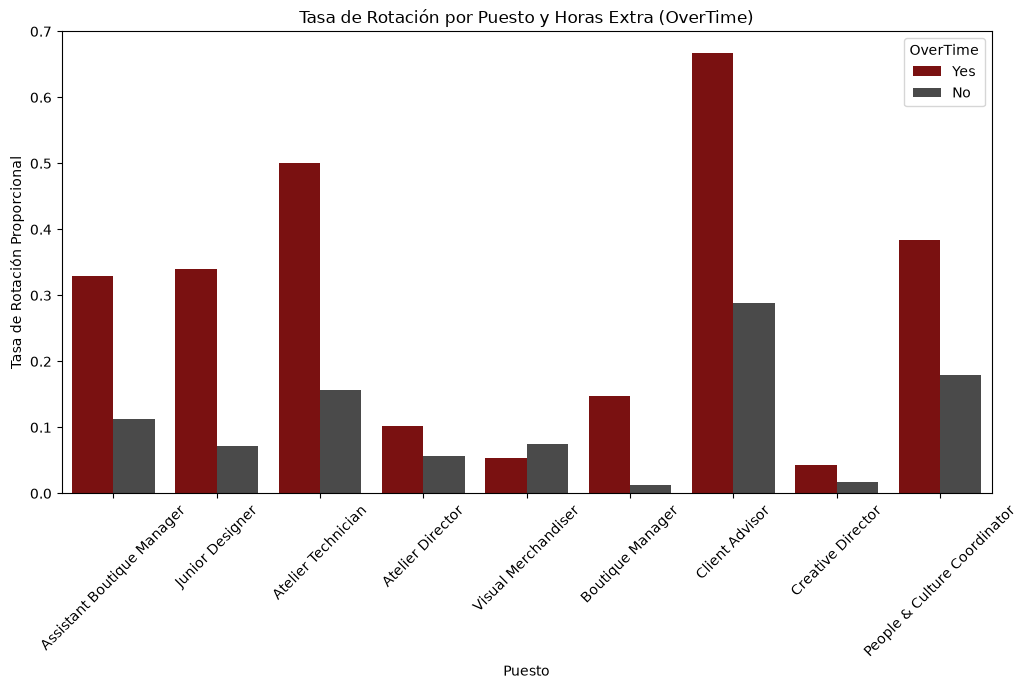

In [17]:
plt.figure(figsize=(12, 6))

# Un tono neutro para 'No' y un rojo/vino de alerta para 'Yes'
colores_lux = ['#8B0000', '#4A4A4A'] 

sns.barplot(
    data=df,
    x='JobRole_Luxury',
    y='Attrition_num',
    hue='OverTime',
    palette=colores_lux,
    errorbar=None
)

plt.title('Tasa de Rotación por Puesto y Horas Extra (OverTime)')
plt.ylabel('Tasa de Rotación Proporcional')
plt.xlabel('Puesto')
plt.xticks(rotation=45)

plt.show()

In [18]:
# Años promedio desde el último ascenso
# Nota: A primera vista, los que renuncian tienen menos años en promedio (1.95 vs 2.23)
df.groupby('Attrition')['YearsSinceLastPromotion'].mean().round(2)

Attrition
No     2.23
Yes    1.95
Name: YearsSinceLastPromotion, dtype: float64

In [19]:
# Ratio de Estancamiento (Promoción / Antigüedad)
# Mide qué porcentaje de su carrera total en la empresa han pasado sin ascenso.
# Resultado: Quienes renuncian sufren un mayor estancamiento relativo (34% vs 29%)
(df['YearsSinceLastPromotion'] / df['YearsAtCompany']).groupby(df['Attrition']).mean().round(2)

Attrition
No     0.29
Yes    0.34
dtype: float64

In [20]:
# Ratio de Estancamiento por Puesto de Lujo y Rotación
# Mide la proporción promedio de la carrera transcurrida sin ascenso

df['Stagnation_Ratio'] = df['YearsSinceLastPromotion'] / df['YearsAtCompany']

(df.groupby(['JobRole_Luxury', 'Attrition'])['Stagnation_Ratio'].mean().round(2).unstack())

Attrition,No,Yes
JobRole_Luxury,,
Assistant Boutique Manager,0.29,0.45
Atelier Director,0.27,0.17
Atelier Technician,0.27,0.27
Boutique Manager,0.36,0.47
Client Advisor,0.39,0.26
Creative Director,0.28,0.55
Junior Designer,0.28,0.39
People & Culture Coordinator,0.27,0.23
Visual Merchandiser,0.31,0.25


In [21]:
# Análisis de compensación: Sueldo Promedio Mensual por Puesto y Rotación
df.groupby(['JobRole_Luxury', 'Attrition'])['MonthlyIncome'].mean().round(2).unstack()

Attrition,No,Yes
JobRole_Luxury,,
Assistant Boutique Manager,6804.62,7489.00
Atelier Director,7289.93,7365.50
Atelier Technician,3337.22,2919.26
Boutique Manager,17201.48,16797.40
Client Advisor,2798.44,2364.73
Creative Director,15947.35,19395.50
Junior Designer,3328.12,2780.47
People & Culture Coordinator,4391.75,3715.75
Visual Merchandiser,7453.56,8548.22


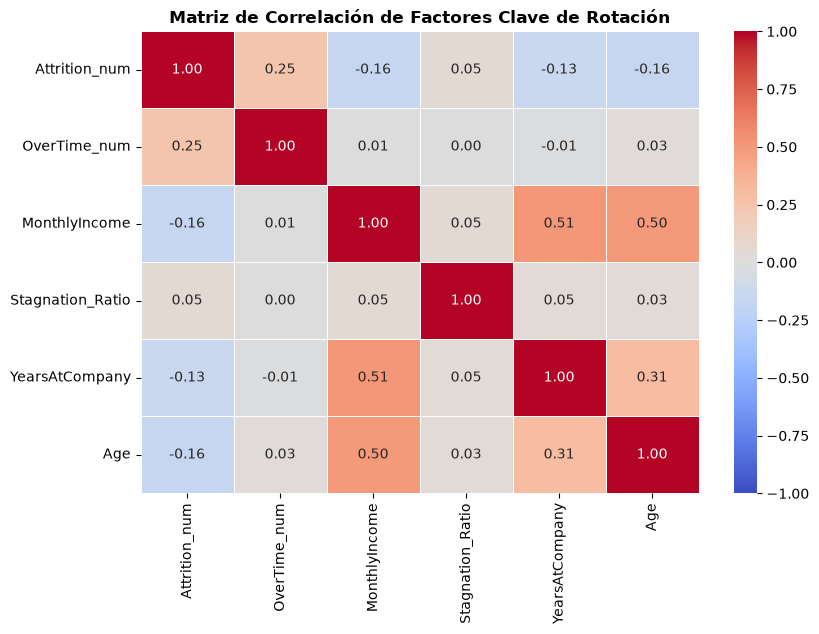

In [35]:
# Generamos un heatmap para mostrar visualmente que factores tienen mayor correlación con la rotación del personal
plt.figure(figsize=(9, 6))

# Matriz de correlación previa
cols_interes = ['Attrition_num', 'OverTime_num', 'MonthlyIncome', 'Stagnation_Ratio', 'YearsAtCompany', 'Age']
corr_matrix = df[cols_interes].corr()

# Generación del Heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

plt.title('Matriz de Correlación de Factores Clave de Rotación', fontsize=12, fontweight='bold')
plt.show()

OverTime_num ($+0.25$): Es, por un margen claro, el factor individual cuantitativo que más se correlaciona con la renuncia.

MonthlyIncome ($-0.16$) y Age ($-0.16$): Correlación negativa moderada. A menor sueldo y menor edad, mayor probabilidad de rotación.

Hipotesis para la prueba de chi-cuadrada

Hipótesis Nula ($H_0$): El género y la rotación son independientes. (No hay relación; la tasa de renuncia es similar en hombres y mujeres).

Hipótesis Alternativa ($H_1$): El género y la rotación están asociados. (El género influye en la probabilidad de renunciar).

In [26]:
# Crear tabla de contingencia de frecuencias
tabla_contingencia = pd.crosstab(df['Gender'], df['Attrition'])
tabla_contingencia

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


In [27]:
from scipy.stats import chi2_contingency

# Calcular el test de Chi-Cuadrado
chi2, p_val, dof, expected = chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-value: {p_val:.4f}")

Estadístico Chi2: 1.1170
p-value: 0.2906


Conclusión: p-value (0.29) > 0.05. No hay asociación significativa entre género y renuncia.

PRUEBA DE HIPÓTESIS: Chi-Cuadrado (Estado Civil vs. Rotación)

H0: El estado civil y la rotación son independientes.

H1: El estado civil influye significativamente en la rotación.

In [28]:
# Tabla contingencia estado civil vs rotación
tabla_contingencia_1 = pd.crosstab(df['MaritalStatus'], df['Attrition'])
tabla_contingencia_1

Attrition,No,Yes
MaritalStatus,,
Divorced,294,33
Married,589,84
Single,350,120


In [30]:
# Calcular el test de Chi-Cuadrado
chi2, p_val, dof, expected = chi2_contingency(tabla_contingencia_1)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-value: {p_val:.4f}")

Estadístico Chi2: 46.1637
p-value: 0.0000


Conclusión: p-value < 0.05 (0.0000). Rechazamos H0. 
    
El Estado Civil es una variable altamente predictiva del riesgo de rotación.

In [32]:
import sqlite3

# 1. Crear conexión a base de datos SQLite en memoria
conn = sqlite3.connect(':memory:')

# 2. Exportar subconjuntos del DataFrame como tablas SQL relacionales
df[['EmployeeNumber', 'Age', 'Gender', 'MaritalStatus', 'JobRole_Luxury']].to_sql('empleados', conn, index=False, if_exists='replace')
df[['EmployeeNumber', 'MonthlyIncome', 'OverTime', 'YearsAtCompany', 'YearsSinceLastPromotion']].to_sql('compensacion_desempeno', conn, index=False, if_exists='replace')
df[['EmployeeNumber', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']].to_sql('encuestas_satisfaccion', conn, index=False, if_exists='replace')
df[['EmployeeNumber', 'Attrition']].to_sql('rotacion', conn, index=False, if_exists='replace')

print("¡Base de datos SQLite configurada y tablas cargadas exitosamente!")

¡Base de datos SQLite configurada y tablas cargadas exitosamente!


In [34]:
query_satisfaccion = """
SELECT 
    c.OverTime,
    r.Attrition,
    ROUND(AVG(s.JobSatisfaction), 2) AS promedio_satisfaccion,
    ROUND(AVG(s.WorkLifeBalance), 2) AS promedio_balance
FROM rotacion r
JOIN compensacion_desempeno c ON r.EmployeeNumber = c.EmployeeNumber
JOIN encuestas_satisfaccion s ON r.EmployeeNumber = s.EmployeeNumber
GROUP BY c.OverTime, r.Attrition;
"""

df_satisfaccion = pd.read_sql_query(query_satisfaccion, conn)
df_satisfaccion

,OverTime,Attrition,promedio_satisfaccion,promedio_balance
0,No,No,2.75,2.79
1,No,Yes,2.36,2.63
2,Yes,No,2.87,2.75
3,Yes,Yes,2.56,2.69


### Diagnóstico de Clima Laboral y Horas Extra (SQL Query)
* **Punto de Quiebre:** Los empleados que hacen horas extra y renuncian presentan un nivel de satisfacción laboral significativamente menor (2.56) frente a sus pares que hacen horas extra pero permanecen (2.87).
* **Conclusión de RH:** Las horas extra por sí solas no causan la renuncia; es la combinación de sobredemanda laboral con baja percepción de reconocimiento/compensación lo que detona la fuga de talento.

¿Cuántos empleados tenemos en riesgo "ALTO", "MEDIO" o "BAJO" basándonos en si hacen horas extra y si su tiempo sin promoción es elevado?

In [36]:
# Segmentación de Empleados por Nivel de Riesgo
# Utiliza CASE WHEN para clasificar a la plantilla cruzando Horas Extra
# con el Estancamiento de Carrera (Años sin promoción >= 3).

query_riesgo = """
SELECT 
    CASE 
        WHEN c.OverTime = 'Yes' AND c.YearsSinceLastPromotion >= 3 THEN 'Riesgo ALTO'
        WHEN c.OverTime = 'Yes' OR c.YearsSinceLastPromotion >= 3 THEN 'Riesgo MEDIO'
        ELSE 'Riesgo BAJO'
    END AS nivel_riesgo,
    COUNT(*) AS total_empleados
FROM empleados e
JOIN compensacion_desempeno c ON e.EmployeeNumber = c.EmployeeNumber
GROUP BY nivel_riesgo;
"""

df_riesgo = pd.read_sql_query(query_riesgo, conn)
df_riesgo

,nivel_riesgo,total_empleados
0,Riesgo ALTO,100
1,Riesgo BAJO,781
2,Riesgo MEDIO,589


**Diagnóstico de Riesgo Operacional (Segmentación General)**
* **Fuga de Talento Focalizada:** El $6.7\%$ de la plantilla ($100$ empleados) se encuentra en **Riesgo ALTO**, enfrentando simultáneamente altas cargas de tiempo extra (`OverTime = 'Yes'`) y un estancamiento de carrera igual o superior a 3 años.
* **Zona de Vulnerabilidad:** Un $39.2\%$ adicional ($589$ empleados) se sitúa en **Riesgo MEDIO**, representando un volumen crítico que requiere monitoreo antes de migrar a riesgo alto por fatiga laboral.
* **Acción Requerida:** La estrategia de retención de People & Culture debe priorizar de inmediato al segmento de **Riesgo ALTO** mediante ajustes promocionales o rediseño de turnos.

In [39]:
query_cte = """
WITH clasificacion_riesgo AS (
    SELECT 
        e.JobRole_Luxury,
        c.OverTime,
        c.YearsSinceLastPromotion,
        CASE 
            WHEN c.OverTime = 'Yes' AND c.YearsSinceLastPromotion >= 3 THEN 'Riesgo ALTO'
            WHEN c.OverTime = 'Yes' OR c.YearsSinceLastPromotion >= 3 THEN 'Riesgo MEDIO'
            ELSE 'Riesgo BAJO'
        END AS nivel_riesgo
    FROM empleados e
    JOIN compensacion_desempeno c ON e.EmployeeNumber = c.EmployeeNumber
)
SELECT 
    JobRole_Luxury,
    COUNT(*) AS total_riesgo_alto
FROM clasificacion_riesgo
WHERE nivel_riesgo = 'Riesgo ALTO'
GROUP BY JobRole_Luxury
ORDER BY total_riesgo_alto DESC;
"""

# Ejecutamos con pandas pasándole la conexión 'conn'
df_top_riesgo = pd.read_sql_query(query_cte, conn)
df_top_riesgo

,JobRole_Luxury,total_riesgo_alto
0,Assistant Boutique Manager,24
1,Junior Designer,18
2,Visual Merchandiser,14
3,Atelier Director,13
4,Boutique Manager,12
5,Atelier Technician,9
6,Creative Director,6
7,Client Advisor,3
8,People & Culture Coordinator,1


**Análisis Estratégico por Puesto de Trabajo (CTE - Riesgo Alto)**
* **Foco Crítico en Gestión de Boutiques:** El rol de **Assistant Boutique Manager** encabeza la lista con $24$ empleados en Riesgo ALTO. Esto confirma que la línea de liderazgo operativo de tienda sufre el mayor punto de presión por sobretrabajo y falta de promoción vertical.
* **Vulnerabilidad Creativa y Artesanal:** Los roles de **Junior Designer** ($18$) y **Visual Merchandiser** ($14$) le siguen en criticidad, sumados a **Atelier Director** ($13$). Esto revela que las áreas de diseño y taller concentran un riesgo severo de pérdida de know-how y talento clave para la identidad de la marca.
* **Implicación Directiva:** La intervención no debe ser generalizada, sino enfocada en reestructurar las rutas de carrera (*career paths*) y la compensación de horas extra en los equipos de tienda, diseño y taller.

In [40]:
# 1. Hacemos una copia del DataFrame completo
df_powerbi = df.copy()

# 2. Agregamos las métricas calculadas creadas en el proyecto
df_powerbi['Stagnation_Ratio'] = (df_powerbi['YearsSinceLastPromotion'] / df_powerbi['YearsAtCompany']).round(2)

# 3. Agregamos la clasificación de Riesgo (la misma regla que usamos en SQL)
def clasificar_riesgo(row):
    if row['OverTime'] == 'Yes' and row['YearsSinceLastPromotion'] >= 3:
        return 'Riesgo ALTO'
    elif row['OverTime'] == 'Yes' or row['YearsSinceLastPromotion'] >= 3:
        return 'Riesgo MEDIO'
    else:
        return 'Riesgo BAJO'

df_powerbi['Nivel_Riesgo'] = df_powerbi.apply(clasificar_riesgo, axis=1)

# 4. Exportamos TODO el dataset enriquecido
df_powerbi.to_csv('HR_Analytics_Luxury_Full.csv', index=False)

print("¡Dataset COMPLETO exportado exitosamente como 'HR_Analytics_Luxury_Full.csv'!")

¡Dataset COMPLETO exportado exitosamente como 'HR_Analytics_Luxury_Full.csv'!


In [41]:
# Aseguramos el motor openpyxl y la extensión .xlsx
df_powerbi.to_excel('HR_Analytics_Luxury_Full.xlsx', engine='openpyxl', index=False)

print("¡Archivo 'HR_Analytics_Luxury_Full.xlsx' generado correctamente!")

¡Archivo 'HR_Analytics_Luxury_Full.xlsx' generado correctamente!
